# Forecasting Sticker Sales - Çıkartma Satışlarının Tahmini

Bu projede, "Forecasting Sticker Sales" veri seti kullanılarak sticker satış miktarlarının tahmin edilmesi amaçlanmıştır. Veri ön işleme adımları uygulandıktan sonra farklı makine öğrenmesi algoritmaları kullanılarak modeller oluşturulmuş ve performansları karşılaştırılmıştır.


### Sütun Açıklamaları

id: Veri setindeki her gözlem (satır) için atanmış benzersiz kimlik numarasıdır. Model eğitimi açısından genellikle bilgi taşımaz ve çoğu zaman analizden çıkarılır.

date: Satışın gerçekleştiği tarihi gösterir. Bu sütundan yıl, ay, gün, hafta günü ve hafta sonu olup olmadığı gibi yeni özellikler üretilebilir.

country: Satışın yapıldığı ülkeyi belirtir. Kategorik bir değişkendir ve farklı ülkelerdeki satış davranışlarını temsil eder.

store: Satışın gerçekleştiği mağazayı ifade eder. Kategorik bir değişkendir ve mağazalar arasındaki satış farklılıklarının analiz edilmesinde kullanılır.

product: Satılan sticker (çıkartma) ürününün adını belirtir. Kategorik bir değişkendir ve ürün bazında satış tahmini yapılmasını sağlar.

num_sold: Satılan ürün adedini gösterir. Bu yarışmadaki hedef değişkendir (target variable). Modelin tahmin etmeye çalışacağı değer bu sütundur.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s5e1/sample_submission.csv
/kaggle/input/competitions/playground-series-s5e1/train.csv
/kaggle/input/competitions/playground-series-s5e1/test.csv


In [2]:
# Veri İşleme
import numpy as np
import pandas as pd

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Uyarıları Gizleme
import warnings
warnings.filterwarnings("ignore")

# Ön İşleme
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Veri Bölme
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# Modeller
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Performans Ölçümleri
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Görünüm Ayarları
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style="whitegrid")

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/playground-series-s5e1/sample_submission.csv
/kaggle/input/competitions/playground-series-s5e1/train.csv
/kaggle/input/competitions/playground-series-s5e1/test.csv


In [4]:
import pandas as pd

train = pd.read_csv('/kaggle/input/competitions/playground-series-s5e1/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s5e1/test.csv')

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.head()

Train Shape: (230130, 6)
Test Shape: (98550, 5)


,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230130 entries, 0 to 230129
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id        230130 non-null  int64  
 1   date      230130 non-null  object 
 2   country   230130 non-null  object 
 3   store     230130 non-null  object 
 4   product   230130 non-null  object 
 5   num_sold  221259 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 10.5+ MB


In [6]:
train.columns

Index(['id', 'date', 'country', 'store', 'product', 'num_sold'], dtype='object')

In [7]:
train.isnull().sum()

id             0
date           0
country        0
store          0
product        0
num_sold    8871
dtype: int64

In [8]:
train[train['num_sold'].isnull()].head()

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
45,45,2010-01-01,Kenya,Discount Stickers,Holographic Goose,NaN
90,90,2010-01-02,Canada,Discount Stickers,Holographic Goose,NaN
135,135,2010-01-02,Kenya,Discount Stickers,Holographic Goose,NaN
180,180,2010-01-03,Canada,Discount Stickers,Holographic Goose,NaN


In [9]:
train[train['num_sold'].isnull()].shape

(8871, 6)

In [10]:
train[train['num_sold'].isnull()]['product'].value_counts()

product
Holographic Goose     8806
Kerneler                64
Kerneler Dark Mode       1
Name: count, dtype: int64

In [11]:
train[train['num_sold'].isnull()]['country'].value_counts()

country
Kenya     4625
Canada    4246
Name: count, dtype: int64

In [12]:
train[train['num_sold'].isnull()]['store'].value_counts()

store
Discount Stickers       5179
Stickers for Less       2666
Premium Sticker Mart    1026
Name: count, dtype: int64

In [13]:
train.groupby('product')['num_sold'].agg(['count','mean','median','min','max'])

,count,mean,median,min,max
product,,,,,
Holographic Goose,37220,197.484363,192.0,5.0,908.0
Kaggle,46026,1232.384587,1215.0,10.0,5939.0
Kaggle Tiers,46026,1018.344110,1007.0,8.0,4958.0
Kerneler,45962,556.913102,537.0,5.0,2496.0
Kerneler Dark Mode,46025,651.042021,617.0,5.0,3127.0


In [14]:
train[train['product'] == 'Holographic Goose']['num_sold'].describe()

count    37220.000000
mean       197.484363
std        120.249103
min          5.000000
25%        113.000000
50%        192.000000
75%        253.000000
max        908.000000
Name: num_sold, dtype: float64

In [15]:
train['num_sold'].fillna(train['num_sold'].median(), inplace=True)

In [16]:
train.isnull().sum()

id          0
date        0
country     0
store       0
product     0
num_sold    0
dtype: int64

In [17]:
from sklearn.preprocessing import LabelEncoder

for col in ['country', 'store', 'product']:
    le = LabelEncoder()

    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

In [18]:
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

for df in [train, test]:
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek

In [19]:
train.drop(['id', 'date'], axis=1, inplace=True)
test.drop(['id', 'date'], axis=1, inplace=True)

In [20]:
train.head()

,country,store,product,num_sold,year,month,day,dayofweek
0,0,0,0,605.0,2010,1,1,4
1,0,0,1,973.0,2010,1,1,4
2,0,0,2,906.0,2010,1,1,4
3,0,0,3,423.0,2010,1,1,4
4,0,0,4,491.0,2010,1,1,4


In [21]:
test.head()

,country,store,product,year,month,day,dayofweek
0,0,0,0,2017,1,1,6
1,0,0,1,2017,1,1,6
2,0,0,2,2017,1,1,6
3,0,0,3,2017,1,1,6
4,0,0,4,2017,1,1,6


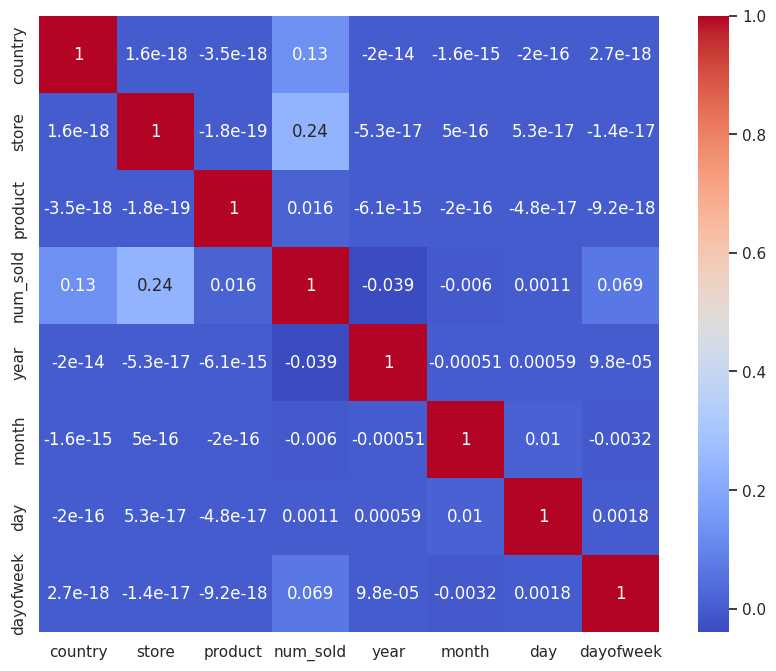

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(train.corr(), annot=True, cmap='coolwarm')
plt.show()

In [29]:
train_sample = train.sample(n=10000, random_state=42)

x = train_sample.drop('num_sold', axis=1)
y = train_sample['num_sold']

In [30]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    )
}

for name, model in models.items():

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    print(f"\n{name}")
    print("R² Score :", round(r2_score(y_test, y_pred), 4))
    print("MAE      :", round(mean_absolute_error(y_test, y_pred), 4))


Linear Regression
R² Score : 0.0906
MAE      : 499.3334

Decision Tree
R² Score : 0.9648
MAE      : 71.4825

Random Forest
R² Score : 0.9805
MAE      : 56.3174


## Sonuç

Uygulanan regresyon modelleri karşılaştırıldığında en başarılı sonucun Random Forest modeli ile elde edildiği görülmüştür. Random Forest modeli 0,9805 R² skoru ve 56,32 MAE değeri ile satış miktarlarını yüksek doğrulukla tahmin etmiştir. Decision Tree modeli de başarılı sonuçlar verirken, Linear Regression modeli veri setinin yapısını yeterince açıklayamamıştır. Elde edilen sonuçlar, satış tahmini probleminde ağaç tabanlı regresyon modellerinin daha etkili olduğunu göstermektedir.
